# Parking entrance staffing study
CSS142P Modelling and Simulation | Group 8

Campus parking management is the decision-maker. The question is how much a second guard reduces delay under the assumed entrance rules.

Compare one guard all day, a second guard from 07:00 to 09:00, and a second guard from 07:00 to 10:00. Test each at 80%, 100%, and 120% expected arrival demand.

The submitted proposal describes independent booths. This notebook assumes guards sharing one ID reader. The group reported sticker checks before ID taps. That account does not confirm the reader count or every pre-check rule. Acceptance of this revision is not established.

A model describes selected entrance rules. A simulation applies those rules to generated cars. Its results describe the model under its inputs.

Read the entrance diagram and inputs before the checks and results. Run all cells with the project Python environment. This notebook updates only result tables and figures.

## 0. Running in Google Colab
Open this notebook in Colab and choose **Runtime → Run all**. The next cell runs only in Colab: it downloads the project files (model code, inputs and tools) from the group's GitHub repository and installs SimPy. On a local machine it does nothing, so the uv workflow in the README is unchanged.

In [1]:
# Colab-only setup. Outside Colab this cell does nothing.
import os, sys, subprocess
if "google.colab" in sys.modules:
    REPO_URL = "https://github.com/10Plaiz/142-modelling.git"
    CLONE_DIR = "/content/142-modelling"
    if not os.path.exists("parking_sim.py"):
        if not os.path.exists(CLONE_DIR):
            subprocess.run(["git", "clone", "-q", REPO_URL, CLONE_DIR], check=True)
        os.chdir(os.path.join(CLONE_DIR, "Group8_Parking_Booth_Simulation"))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "simpy==4.1.2"], check=True)
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())
    print("Colab setup complete. Working folder:", os.getcwd())
else:
    print("Not running in Colab; no setup needed.")

Not running in Colab; no setup needed.


## 1. Reproducible setup
Use Python 3.12 from the repository's uv environment. Internal time is minutes after 07:00. Delay is displayed in seconds.

A replication is one simulated operating day. Different seeds produce independent days. Within a day and demand level, all schedules receive matching cars and activity times.

A scenario combines a staffing schedule and an input condition. The main comparison has nine scenarios. The additional timing test changes activity times at normal arrival demand.

In [2]:
import hashlib
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
import parking_sim as ps

if os.environ.get("PARKING_EXPECTED_PREFIX"):
    assert Path(sys.prefix) == Path(os.environ["PARKING_EXPECTED_PREFIX"]), "Wrong notebook Python environment"
DATA, RESULTS, FIGS = map(Path, ["data", "results", "figures"])
for directory in [RESULTS, FIGS]:
    directory.mkdir(exist_ok=True)
input_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA.glob("*.csv")}
rates, parameters, K, model = ps.load_inputs(DATA)
DEMAND_LEVELS = [0.8, 1.0, 1.2]
PILOT_REPS = 30
TARGETS = {"avg_delay_sec": 1.0, "max_queue_veh": 1.0, "guard_utilization": 0.01, "spillover_min": 1.0,
           "avg_delay_morning_sec": 1.0, "avg_initial_wait_sec": 1.0}
MEASURES = {
    "avg_delay_sec": ("Average total delay", "seconds"),
    "max_queue_veh": ("Daily maximum approach queue", "cars"),
    "guard_utilization": ("Guard utilization", "fraction"),
    "spillover_min": ("Spillover duration", "minutes"),
}
SUPPLEMENTARY = {
    "avg_delay_morning_sec": ("Delay for morning arrivals", "seconds"),
    "avg_initial_wait_sec": ("Initial waiting time", "seconds"),
    "effective_guard_hours": ("Effective available guard-hours", "hours"),
}
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Python:", sys.executable)
print("Estimated campus inputs. No field validation. K =", K)
display(pd.DataFrame([{"schedule": c.name, "scheduled_guard_hours": c.guard_hours} for c in ps.CONFIGS]))

Python: /home/claude/repo/.venv/bin/python3
Estimated campus inputs. No field validation. K = 8


,schedule,scheduled_guard_hours
0,A: 1 guard,12.0
1,B: 2nd guard 07-09,14.0
2,C: 2nd guard 07-10,15.0


## 2. How the assumed entrance works
One car is an entity. Its arrival time and sticker status are attributes. The guards and entrance positions have limited capacity.

With one guard, a car receives its sticker check at the entrance stop. It then taps its ID and enters. A car without a sticker is refused and turns out.

Guard 2 checks the next car while the stop is occupied. A checked car holds its pre-check position until the stop is free. Both guards share one final entrance stop.

The approach queue includes the pre-check position and excludes the entrance stop. A pre-check car can receive service while it remains on the approach.

Each day starts empty at 07:00. Arrivals stop at 19:00. Remaining cars finish processing. Parking-space availability, exit traffic, abandonment, and reader breakdowns are outside the model.

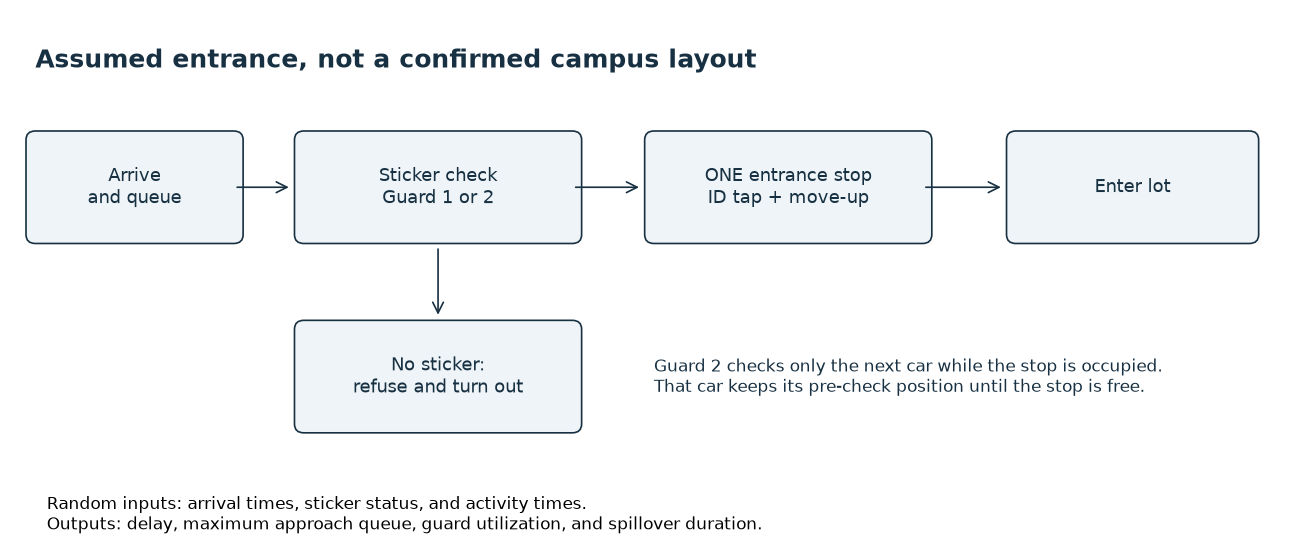

In [3]:
from tools.build_presentation import draw_entrance
fig = draw_entrance()
fig.set_size_inches(11, 5)
fig.subplots_adjust(bottom=.22)
fig.text(.04, .10, "Random inputs: arrival times, sticker status, and activity times.\n"
         "Outputs: delay, maximum approach queue, guard utilization, and spillover duration.",
         fontsize=10)
fig.savefig(FIGS / "conceptual_model.png", bbox_inches="tight")
plt.show()

## 3. Inputs and measures
Inputs are supplied values and policies. Outputs are calculated from simulated behavior.

All campus values are estimates. The parameter CSV records a basis and source. Many entries identify only a group estimate. The arrival CSV contains rates without source columns. The historical PR #2 report attributes the profile to Study B. Its selected rates lack a documented derivation.

Lognormal times stay positive and allow some activities to take longer. These properties make the distribution plausible. They do not prove that it describes campus timings. Its parameters come from estimated means and standard deviations, not stopwatch samples.

Arrival rates vary by 15-minute interval. A Poisson process generates randomly spaced arrivals. Campus observations have not established this assumption.

| Measure | Unit and definition |
| --- | --- |
| Total delay | Seconds. Departure minus arrival minus the car's own activity time. |
| Initial waiting time | Seconds. Arrival until the first sticker check starts. |
| Maximum approach queue | Cars. Largest approach count in a day, including the pre-check position. |
| Guard utilization | Fraction. Active checks and refusals divided by available guard-time. |
| Spillover duration | Minutes. Time the approach count is at least estimated K = 8. |
| Guard-hours | Hours. Scheduled totals are 12, 14, and 15. Effective totals include final guard activity after closing. |

ID tapping and movement occupy the stop but do not count as active guard work. Morning delay applies to cars arriving from 07:00 up to, but not including, 10:00.

,input,status,basis
0,Arrival profile,estimated,Study B group estimate; interval-rate derivati...
1,Activity moments,estimated,Parameter CSV; no stopwatch samples
2,No-sticker share and K,estimated,Parameter CSV; no measured share or approach c...
3,Entrance layout,assumed,PR #2 revision; full layout not confirmed


,parameter,value,unit,basis,source
0,nonsticker_share,0.05,fraction of arrivals,ESTIMATED. Share of arriving cars without a pa...,"Group estimate, carried over from Study B (CSS..."
1,check_mean_sec,4.00,seconds,ESTIMATED. C: guard looks at the windshield st...,Group estimate from first-hand experience of t...
2,check_sd_sec,2.00,seconds,ESTIMATED. Spread of C.,Group estimate
3,tap_mean_sec,4.00,seconds,"ESTIMATED. T: driver reaches out, taps the Uni...",Group estimate; card/RFID transaction range fr...
4,tap_sd_sec,2.00,seconds,ESTIMATED. Spread of T.,Group estimate
5,moveup_mean_sec,3.00,seconds,ESTIMATED. M: the car clears the barrier and t...,Group estimate
6,moveup_sd_sec,1.00,seconds,ESTIMATED. Spread of M.,Group estimate
7,refusal_mean_sec,45.00,seconds,ESTIMATED. R: guard explains the refusal and t...,"Group estimate, carried over from Study B"
8,refusal_sd_sec,15.00,seconds,ESTIMATED. Spread of R.,"Group estimate, carried over from Study B"
9,K_waiting_spaces,8.00,vehicles,"ESTIMATED. Cars that fit on the approach, not ...","Group estimate, carried over from Study B"


Expected arrivals/day: 401.75; 07:00-10:00: 213.75
Mean time occupying the one-guard stop, including refusals: 12.90 seconds


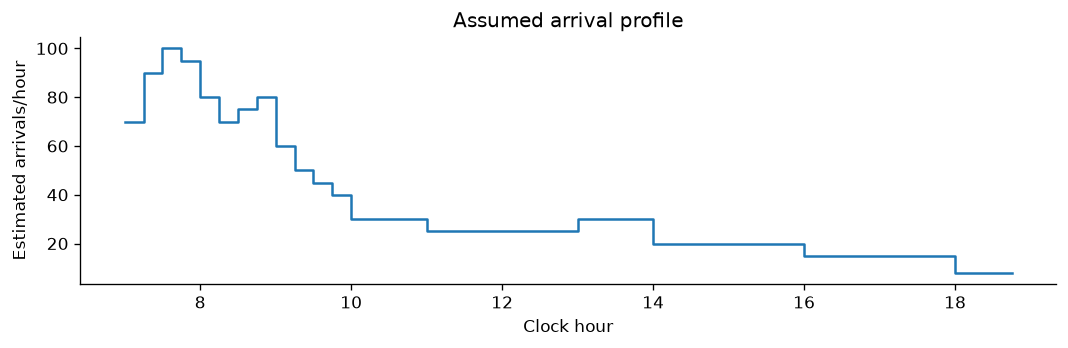

In [4]:
input_provenance = pd.DataFrame([
    {"input": "Arrival profile", "status": "estimated", "basis": "Study B group estimate; interval-rate derivation unavailable"},
    {"input": "Activity moments", "status": "estimated", "basis": "Parameter CSV; no stopwatch samples"},
    {"input": "No-sticker share and K", "status": "estimated", "basis": "Parameter CSV; no measured share or approach capacity"},
    {"input": "Entrance layout", "status": "assumed", "basis": "PR #2 revision; full layout not confirmed"},
])
input_provenance.to_csv(RESULTS / "input_provenance.csv", index=False)
display(input_provenance)
display(parameters)
arrivals_table = pd.read_csv(DATA / "arrival_rates.csv")
es, es2 = model.moments(admitted_at_stop=False)
arrivals_table["expected_cars_per_slot"] = rates * ps.INTERVAL
arrivals_table["one_guard_stop_load"] = rates * es
arrivals_table.to_csv(RESULTS / "arrival_rates_and_load.csv", index=False)
print(f"Expected arrivals/day: {rates.sum() * ps.INTERVAL:.2f}; 07:00-10:00: {rates[:12].sum() * ps.INTERVAL:.2f}")
print(f"Mean time occupying the one-guard stop, including refusals: {es * 60:.2f} seconds")
fig, ax = plt.subplots(figsize=(9, 3))
ax.step(np.arange(48) / 4 + 7, rates * 60, where="post")
ax.set(xlabel="Clock hour", ylabel="Estimated arrivals/hour", title="Assumed arrival profile")
fig.tight_layout(); fig.savefig(FIGS / "arrival_profile.png"); plt.show()

## 4. Does the program follow its rules?
Verification checks the implementation. It does not establish that estimated inputs describe the campus.

Small examples have known answers. Known-answer queue benchmarks exercise the same event code under separate steady-state conditions. Only those benchmarks discard a warm-up. The main daily experiment starts empty and discards no warm-up.

In [5]:
checks = []
def check(name, expected, observed, passed):
    checks.append({"check": name, "expected": str(expected), "observed": str(observed), "pass": bool(passed)})
    pd.DataFrame(checks).to_csv(RESULTS / "verification_checks.csv", index=False)
    assert passed, f"{name}: expected {expected}; observed {observed}"

def fixed_day(arrivals, service, cfg=ps.ONE_GUARD):
    arrivals, service = np.asarray(arrivals, float), np.asarray(service, float)
    acts = {"check": service, "tap": np.zeros(len(service)), "moveup": np.zeros(len(service)), "refusal": np.zeros(len(service))}
    return ps.simulate_day(arrivals, np.zeros(len(service), bool), acts, cfg)

d = fixed_day([2, 6, 7, 10], [3, 2, 4, 1])
delay = d.depart - d.arrival - d.activity
check("V1 hand trace", "[0, 0, 1, 2]; mean 0.75; busy fraction 10/13",
      delay.tolist(), np.allclose(delay, [0, 0, 1, 2]) and np.isclose(delay.mean(), .75) and np.isclose(d.guard_busy[1] / d.depart.max(), 10/13))
d = fixed_day(np.arange(50), np.full(50, .99))
check("V2 deterministic no waiting", 0, (d.depart-d.arrival-d.activity).max(), np.allclose(d.depart-d.arrival-d.activity, 0))
arr = np.array([0., 1., 2.])
acts = {"check": np.full(3, 2.), "tap": np.full(3, 3.), "moveup": np.zeros(3), "refusal": np.zeros(3)}
for cfg, expected in [(ps.ONE_GUARD, [5, 10, 15]), (ps.GUARD2_TO_09, [5, 8, 11])]:
    d = ps.simulate_day(arr, np.zeros(3, bool), acts, cfg)
    check("V11 two-station trace " + cfg.name, expected, d.depart.tolist(), np.allclose(d.depart, expected))

a, non, acts = ps.replication_inputs(712, rates, model, demand=1.2)
base = ps.simulate_day(a, non, acts, ps.ONE_GUARD)
closed = ps.simulate_day(a, non, acts, ps.Config("closed at opening", 0., 12.))
check("V12 guard closed at opening", "same departures as A", np.max(abs(base.depart-closed.depart)), np.allclose(base.depart, closed.depart))
zero_check = {**acts, "check": np.zeros(len(a))}
d1 = ps.simulate_day(a, np.zeros(len(a), bool), zero_check, ps.ONE_GUARD)
d2 = ps.simulate_day(a, np.zeros(len(a), bool), zero_check, ps.GUARD2_TO_09)
check("V12 zero check and no refusals", "same departures", np.max(abs(d1.depart-d2.depart)), np.allclose(d1.depart,d2.depart))
a0, n0, x0 = ps.replication_inputs(1, np.zeros_like(rates), model)
empty = ps.simulate_day(a0, n0, x0, ps.GUARD2_TO_09)
m0 = ps.day_metrics(empty, K)
check("Empty-input case", "zero cars, delay, queue, spillover", m0["n_vehicles"], all(m0[k] == 0 for k in ["n_vehicles","avg_delay_sec","max_queue_veh","spillover_min"]))
a1, n1, x1 = ps.replication_inputs(31, rates, model, .8)
a2, n2, x2 = ps.replication_inputs(31, rates, model, 1.2)
check("V8 reproducible streams across demand", "same types and activities for common car indices",
      len(a1), np.array_equal(n1,n2[:len(n1)]) and all(np.array_equal(x1[k],x2[k][:len(a1)]) for k in ps.ACTIVITIES))
a1b, n1b, x1b = ps.replication_inputs(31, rates, model, .8)
check("V8 seed reproducibility", "identical inputs", "compared arrays",
      np.array_equal(a1,a1b) and np.array_equal(n1,n1b) and all(np.array_equal(x1[k],x1b[k]) for k in ps.ACTIVITIES))
print("Small deterministic and reproducibility checks passed.")

import tempfile
import shutil
with tempfile.TemporaryDirectory(prefix="parking-invalid-input-") as fixture:
    fixture = Path(fixture)
    for name in ["arrival_rates.csv", "input_parameters.csv"]:
        shutil.copy2(DATA / name, fixture / name)
    def rejected(name):
        try:
            ps.load_inputs(fixture)
        except ValueError as error:
            check(name, "clear input error", error, True)
        else:
            check(name, "input rejected", "accepted", False)
    original_arrivals = pd.read_csv(DATA / "arrival_rates.csv")
    bad = original_arrivals.copy()
    bad.loc[0, "arrivals_per_hour"] = -1
    bad.to_csv(fixture / "arrival_rates.csv", index=False)
    rejected("Invalid negative arrival rate")
    original_arrivals.iloc[:-1].to_csv(fixture / "arrival_rates.csv", index=False)
    rejected("Invalid missing arrival slot")
    original_arrivals.to_csv(fixture / "arrival_rates.csv", index=False)
    original_params = pd.read_csv(DATA / "input_parameters.csv")
    for parameter, value, label in [("nonsticker_share", 1.1, "Invalid sticker probability"),
                                    ("K_waiting_spaces", 1.5, "Invalid fractional spillover threshold")]:
        bad = original_params.copy()
        bad.loc[bad.parameter == parameter, "value"] = value
        bad.to_csv(fixture / "input_parameters.csv", index=False)
        rejected(label)
print("Invalid-input checks passed without changing campus inputs.")


Small deterministic and reproducibility checks passed.
Invalid-input checks passed without changing campus inputs.


In [6]:
def known_answer(family):
    estimates = []
    if family == "M/M/1":
        mean_s, lam, theory = 1., .8, ps.mm1_wq(.8, 1.)
    else:
        mean_s = es
        lam = .7 / mean_s
        theory = ps.pk_wq(lam, es, es2)
    horizon, warmup = 20000 * mean_s, 1000 * mean_s
    for seed in range(1001, 1021):
        streams = np.random.SeedSequence(seed).spawn(6)
        rng = np.random.default_rng(streams[0])
        arrivals = np.cumsum(rng.exponential(1/lam, int(lam*horizon*1.2)+500))
        arrivals = arrivals[arrivals < horizon]
        count = len(arrivals)
        if family == "M/M/1":
            non = np.zeros(count, bool)
            acts = {"check": np.random.default_rng(streams[1]).exponential(mean_s,count),
                    "tap": np.zeros(count), "moveup": np.zeros(count), "refusal": np.zeros(count)}
        else:
            non = np.random.default_rng(streams[1]).random(count) < model.share_nonsticker
            acts = model.times({k: np.random.default_rng(streams[i+2]).random(count) for i,k in enumerate(ps.ACTIVITIES)})
        day = ps.simulate_day(arrivals,non,acts,ps.ONE_GUARD,day_length=horizon)
        delay = day.depart-day.arrival-day.activity
        estimates.append(delay[arrivals >= warmup].mean())
    ci = ps.ci_mean(estimates)
    tolerance = max(.05 * theory, 3 * ci["se"])
    check("V9 " + family + " known answer", f"{theory:.6f} min; tolerance {tolerance:.6f}",
          ci["mean"], abs(ci["mean"]-theory) <= tolerance)
    return {"benchmark":family,"theory_min":theory,"tolerance_min":tolerance,**ci}
benchmarks = pd.DataFrame([known_answer("M/M/1"),known_answer("M/G/1")])
benchmarks.to_csv(RESULTS / "known_answer_benchmarks.csv", index=False)
display(benchmarks[["benchmark","theory_min","mean","ci_low","ci_high","tolerance_min"]])

,benchmark,theory_min,mean,ci_low,ci_high,tolerance_min
0,M/M/1,4.000000,3.845732,3.674888,4.016576,0.244876
1,M/G/1,0.384367,0.385509,0.372409,0.398609,0.019218


## 5. Experiment settings and replication precision
The pilot uses seeds 1 to 30 for each of the nine required scenarios. Activity distributions, refusal share, and K stay fixed during arrival-demand sensitivity.

The Week 7 planning rule estimates the run count from the current and desired confidence-interval half-widths. The study checks achieved precision after any additional runs.

Targets are 1 second for all-day delay, morning delay, and initial waiting; 1 car for maximum queue; 1 minute for spillover; and 0.01 for utilization. They apply to schedule means and paired differences.

These are simulation precision targets. They are not acceptable waiting-time limits for campus operations. Intervals do not cover all input uncertainty.

In [7]:
def run_grid(n):
    frames, grid_days = [], {}
    for demand in DEMAND_LEVELS:
        frame, days = ps.run_experiment(range(1,n+1),rates,model,K,demand=demand,keep_days=True)
        frame["demand"] = demand
        frames.append(frame)
        grid_days[demand] = days
    return pd.concat(frames,ignore_index=True), grid_days

def precision_plan(frame, group_field="demand"):
    rows = []
    for demand in sorted(frame[group_field].unique()):
        group = frame[frame[group_field] == demand]
        by = {cfg.name: group[group.config == cfg.name].set_index("seed").sort_index() for cfg in ps.CONFIGS}
        for metric,target in TARGETS.items():
            quantities = [(c.name,by[c.name][metric].to_numpy()) for c in ps.CONFIGS]
            quantities += [(b.name+" minus "+a.name, (by[b.name][metric]-by[a.name][metric]).to_numpy()) for a,b in ps.COMPARISONS]
            for quantity,values in quantities:
                ci = ps.ci_mean(values)
                rows.append({group_field:demand,"quantity":quantity,"measure":metric,"target":target,
                             "recommended_n":max(PILOT_REPS,ps.replications_needed(len(values),ci["half_width"],target)),
                             "target_met":ci["half_width"]<=target,**ci})
    return pd.DataFrame(rows)

raw, grid_days = run_grid(PILOT_REPS)
pilot_plan = precision_plan(raw)
pilot_plan.to_csv(RESULTS / "replication_planning.csv",index=False)
final_n = PILOT_REPS
for attempt in range(4):
    plan = precision_plan(raw)
    if plan.target_met.all() or final_n >= 300:
        break
    final_n = min(300,max(final_n+1,int(plan.recommended_n.max())))
    raw, grid_days = run_grid(final_n)
plan = precision_plan(raw)
plan.to_csv(RESULTS / "replication_followup.csv",index=False)
raw.drop(columns=[c for c in raw if c.startswith("_")]).to_csv(RESULTS / "replications_raw.csv",index=False)
print(f"Final n = {final_n} per schedule-demand combination; {len(raw)} simulated days.")
print("All precision targets met:", bool(plan.target_met.all()))
display(plan[["demand","quantity","measure","n","half_width","target","target_met"]])

Final n = 30 per schedule-demand combination; 270 simulated days.
All precision targets met: True


,demand,quantity,measure,n,half_width,target,target_met
0,0.8,A: 1 guard,avg_delay_sec,30,0.212733,1.0,True
1,0.8,B: 2nd guard 07-09,avg_delay_sec,30,0.165516,1.0,True
2,0.8,C: 2nd guard 07-10,avg_delay_sec,30,0.159443,1.0,True
3,0.8,B: 2nd guard 07-09 minus A: 1 guard,avg_delay_sec,30,0.073106,1.0,True
4,0.8,C: 2nd guard 07-10 minus A: 1 guard,avg_delay_sec,30,0.073558,1.0,True
...,...,...,...,...,...,...,...
103,1.2,B: 2nd guard 07-09,avg_initial_wait_sec,30,0.185273,1.0,True
104,1.2,C: 2nd guard 07-10,avg_initial_wait_sec,30,0.181526,1.0,True
105,1.2,B: 2nd guard 07-09 minus A: 1 guard,avg_initial_wait_sec,30,0.180927,1.0,True
106,1.2,C: 2nd guard 07-10 minus A: 1 guard,avg_initial_wait_sec,30,0.175540,1.0,True


In [8]:
flags = {k: True for k in ["V3","V4","V5","V6","V7","V8","V10","V13"]}
for demand,days in grid_days.items():
    for seed in range(1,final_n+1):
        arrivals, non, acts = ps.replication_inputs(seed,rates,model,demand)
        first = days[(seed,ps.ONE_GUARD.name)]
        for cfg in ps.CONFIGS:
            d = days[(seed,cfg.name)]
            m = ps.day_metrics(d,K)
            snap = d.snapshot_close
            delay = d.depart-d.arrival-d.activity
            flags["V3"] &= snap["arrived"] == sum(snap[k] for k in ["entered","refused","on_approach","at_stop"])
            flags["V4"] &= bool(np.isfinite(d.depart).all() and (delay>=-1e-9).all() and (d.trace_q>=0).all()
                                and 0<=m["guard_utilization"]<=1 and d.trace_q[-1]==0 and (d.depart>=d.arrival).all())
            flags["V5"] &= bool((np.diff(d.at_stop[np.isfinite(d.at_stop)])>=-1e-9).all())
            flags["V6"] &= bool(np.isclose(m["_queue_area"],m["_sum_approach"],rtol=1e-9,atol=1e-8))
            if cfg.guard2_close is not None:
                flags["V7"] &= bool((d.check_start[d.prechecked]<cfg.guard2_close).all())
            flags["V8"] &= bool(np.array_equal(d.arrival,first.arrival) and np.array_equal(d.nonsticker,first.nonsticker)
                                and np.array_equal(d.activity,first.activity))
            admitted = ~non
            flags["V13"] &= bool((d.stop_hold[admitted]>=acts["tap"][admitted]+acts["moveup"][admitted]-1e-9).all())
            if cfg == ps.ONE_GUARD:
                flags["V10"] &= bool(np.allclose(delay,ps.lindley_delays(arrivals,d.activity),rtol=1e-9,atol=1e-8))
names = {"V3":"vehicle conservation at 19:00","V4":"sanity and completed processing","V5":"FIFO arrival order at stop",
         "V6":"queue-area identity","V7":"guard-2 closing rule","V8":"identical cars across schedules",
         "V10":"per-car Lindley recursion","V13":"one-reader holding-time bound"}
for key,passed in flags.items():
    check(key+" "+names[key],"true in all final study runs",f"{len(raw)} runs",passed)
verification = pd.DataFrame(checks)
display(verification)
print("All model checks passed:", bool(verification["pass"].all()))

,check,expected,observed,pass
0,V1 hand trace,"[0, 0, 1, 2]; mean 0.75; busy fraction 10/13","[0.0, 0.0, 1.0, 2.0]",True
1,V2 deterministic no waiting,0,1.9984014443252818e-15,True
2,V11 two-station trace A: 1 guard,"[5, 10, 15]","[5.0, 10.0, 15.0]",True
3,V11 two-station trace B: 2nd guard 07-09,"[5, 8, 11]","[5.0, 8.0, 11.0]",True
4,V12 guard closed at opening,same departures as A,0.0,True
5,V12 zero check and no refusals,same departures,0.0,True
6,Empty-input case,"zero cars, delay, queue, spillover",0,True
7,V8 reproducible streams across demand,same types and activities for common car indices,305,True
8,V8 seed reproducibility,identical inputs,compared arrays,True
9,Invalid negative arrival rate,clear input error,Arrival rates must be finite and nonnegative,True


All model checks passed: True


## 6. Results and staffing comparisons
Means average daily results. Standard deviations describe differences between days. A 95% confidence interval describes uncertainty about a mean.

A daily maximum queue is an integer. Its mean across days can be fractional.

Paired differences use matching days and report alternative minus baseline. A negative delay difference means the alternative saved time. Bonferroni intervals account for three staffing comparisons within each measure and input condition.

The main table keeps the original four measures. Supplementary tables add morning delay, initial waiting, and effective guard-hours. CSV files retain the detailed results.

,configuration,label,unit,n,mean,sd,ci_low,ci_high,scheduled_guard_hours
21,A: 1 guard,Average total delay,seconds,30,2.5686,0.7036,2.3059,2.8313,12.0
22,A: 1 guard,Daily maximum approach queue,cars,30,3.5000,1.0748,3.0987,3.9013,12.0
23,A: 1 guard,Guard utilization,fraction,30,0.0579,0.0053,0.0559,0.0599,12.0
24,A: 1 guard,Spillover duration,minutes,30,0.0000,0.0000,0.0000,0.0000,12.0
28,B: 2nd guard 07-09,Average total delay,seconds,30,1.7992,0.4825,1.6190,1.9794,14.0
29,B: 2nd guard 07-09,Daily maximum approach queue,cars,30,3.5667,1.0726,3.1661,3.9672,14.0
30,B: 2nd guard 07-09,Guard utilization,fraction,30,0.0496,0.0046,0.0479,0.0513,14.0
31,B: 2nd guard 07-09,Spillover duration,minutes,30,0.0000,0.0000,0.0000,0.0000,14.0
35,C: 2nd guard 07-10,Average total delay,seconds,30,1.6965,0.4633,1.5235,1.8695,15.0
36,C: 2nd guard 07-10,Daily maximum approach queue,cars,30,3.6000,1.1326,3.1771,4.0229,15.0


,demand,comparison,measure,extra_guard_hours,n,mean,sd,se,t,half_width,ci_low,ci_high,bonferroni_ci_low,bonferroni_ci_high
21,1.0,B: 2nd guard 07-09 minus A: 1 guard,avg_delay_sec,2.0,30,-0.7694,0.3078,0.0562,2.0452,0.1150,-0.8844,-0.6545,-0.9122,-0.6266
28,1.0,C: 2nd guard 07-10 minus A: 1 guard,avg_delay_sec,3.0,30,-0.8721,0.3002,0.0548,2.0452,0.1121,-0.9842,-0.7600,-1.0114,-0.7328
35,1.0,C: 2nd guard 07-10 minus B: 2nd guard 07-09,avg_delay_sec,1.0,30,-0.1027,0.0630,0.0115,2.0452,0.0235,-0.1262,-0.0792,-0.1319,-0.0735


,demand,configuration,days,spillover_days,p_hat,ci_low,ci_high
0,0.8,A: 1 guard,30,0,0.0,0.0,0.1135
1,0.8,B: 2nd guard 07-09,30,0,0.0,0.0,0.1135
2,0.8,C: 2nd guard 07-10,30,0,0.0,0.0,0.1135
3,1.0,A: 1 guard,30,0,0.0,0.0,0.1135
4,1.0,B: 2nd guard 07-09,30,0,0.0,0.0,0.1135
5,1.0,C: 2nd guard 07-10,30,0,0.0,0.0,0.1135
6,1.2,A: 1 guard,30,0,0.0,0.0,0.1135
7,1.2,B: 2nd guard 07-09,30,0,0.0,0.0,0.1135
8,1.2,C: 2nd guard 07-10,30,0,0.0,0.0,0.1135


Zero observed spillover days still have a positive Wilson upper confidence limit.


,configuration,label,n,mean,sd,ci_low,ci_high
21,A: 1 guard,Average total delay,30,2.569,0.704,2.306,2.831
25,A: 1 guard,Delay for morning arrivals,30,3.978,1.274,3.503,4.454
26,A: 1 guard,Initial waiting time,30,2.569,0.704,2.306,2.831
28,B: 2nd guard 07-09,Average total delay,30,1.799,0.483,1.619,1.979
32,B: 2nd guard 07-09,Delay for morning arrivals,30,2.541,0.883,2.211,2.871
33,B: 2nd guard 07-09,Initial waiting time,30,1.253,0.401,1.103,1.403
35,C: 2nd guard 07-10,Average total delay,30,1.696,0.463,1.523,1.869
39,C: 2nd guard 07-10,Delay for morning arrivals,30,2.347,0.833,2.036,2.658
40,C: 2nd guard 07-10,Initial waiting time,30,1.004,0.392,0.858,1.150


,comparison,mean,ci_low,ci_high,bonferroni_ci_low,bonferroni_ci_high
25,B: 2nd guard 07-09 minus A: 1 guard,-1.438,-1.647,-1.228,-1.698,-1.177
32,C: 2nd guard 07-10 minus A: 1 guard,-1.632,-1.837,-1.426,-1.887,-1.377
39,C: 2nd guard 07-10 minus B: 2nd guard 07-09,-0.194,-0.241,-0.147,-0.252,-0.136


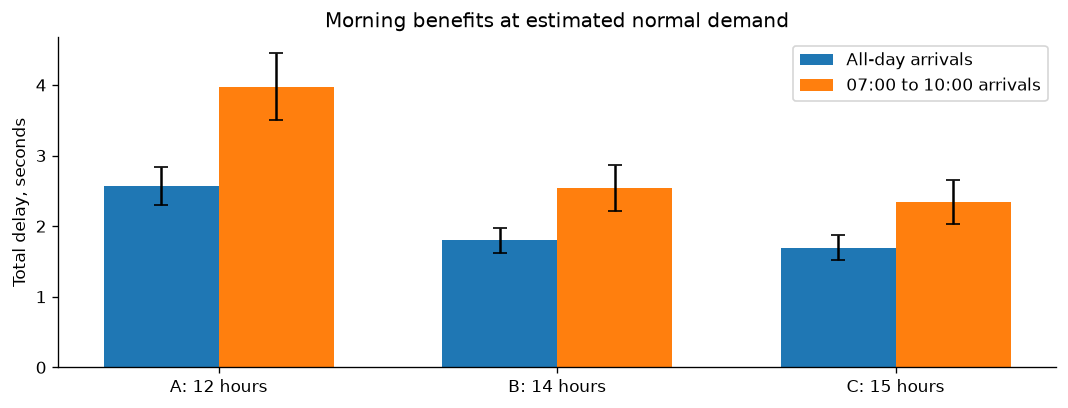

In [9]:
summary_rows, paired_rows, probability_rows = [], [], []
for demand in DEMAND_LEVELS:
    group = raw[raw.demand==demand]
    by = {cfg.name:group[group.config==cfg.name].set_index("seed").sort_index() for cfg in ps.CONFIGS}
    for cfg in ps.CONFIGS:
        sub = by[cfg.name]
        for metric,(label,unit) in {**MEASURES, **SUPPLEMENTARY}.items():
            summary_rows.append({"demand":demand,"configuration":cfg.name,"measure":metric,"label":label,"unit":unit,
                                 "scheduled_guard_hours":cfg.guard_hours,**ps.ci_mean(sub[metric])})
        k = int(sub.any_spillover.sum())
        p,lo,hi = ps.wilson_interval(k,len(sub))
        probability_rows.append({"demand":demand,"configuration":cfg.name,"days":len(sub),"spillover_days":k,
                                 "p_hat":p,"ci_low":lo,"ci_high":hi})
    for a,b in ps.COMPARISONS:
        for metric in {**MEASURES, **SUPPLEMENTARY}:
            difference = by[b.name][metric]-by[a.name][metric]
            ci,adjusted = ps.ci_mean(difference),ps.ci_mean(difference,conf=1-.05/3)
            paired_rows.append({"demand":demand,"comparison":b.name+" minus "+a.name,"measure":metric,
                                "extra_guard_hours":b.guard_hours-a.guard_hours,**ci,
                                "bonferroni_ci_low":adjusted["ci_low"],"bonferroni_ci_high":adjusted["ci_high"]})
all_summary = pd.DataFrame(summary_rows)
all_paired = pd.DataFrame(paired_rows)
summary = all_summary[all_summary.measure.isin(MEASURES)].copy()
paired = all_paired[all_paired.measure.isin(MEASURES)].copy()
supplementary_summary = all_summary[all_summary.measure.isin(SUPPLEMENTARY)].copy()
supplementary_paired = all_paired[all_paired.measure.isin(SUPPLEMENTARY)].copy()
supplementary_summary.to_csv(RESULTS / "supplementary_summary.csv", index=False)
supplementary_paired.to_csv(RESULTS / "supplementary_paired_differences.csv", index=False)
probabilities = pd.DataFrame(probability_rows)
summary.to_csv(RESULTS / "summary_by_config.csv",index=False)
summary.to_csv(RESULTS / "demand_scenarios.csv",index=False)
paired.to_csv(RESULTS / "paired_differences.csv",index=False)
probabilities.to_csv(RESULTS / "spillover_probability.csv",index=False)
display(summary[summary.demand==1.0][["configuration","label","unit","n","mean","sd","ci_low","ci_high","scheduled_guard_hours"]].round(4))
display(paired[(paired.demand==1.0)&(paired.measure=="avg_delay_sec")].round(4))
display(probabilities.round(4))
print("Zero observed spillover days still have a positive Wilson upper confidence limit.")
normal_times = all_summary[(all_summary.demand == 1.) & all_summary.measure.isin(
    ["avg_delay_sec", "avg_delay_morning_sec", "avg_initial_wait_sec"])]
display(normal_times[["configuration", "label", "n", "mean", "sd", "ci_low", "ci_high"]].round(3))
display(supplementary_paired[(supplementary_paired.demand == 1.) &
    (supplementary_paired.measure == "avg_delay_morning_sec")][
    ["comparison", "mean", "ci_low", "ci_high", "bonferroni_ci_low", "bonferroni_ci_high"]].round(3))
fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(3)
for offset, metric, label in [(-.17, "avg_delay_sec", "All-day arrivals"),
                              (.17, "avg_delay_morning_sec", "07:00 to 10:00 arrivals")]:
    sub = normal_times[normal_times.measure == metric]
    ax.bar(x + offset, sub["mean"], width=.34, yerr=sub.half_width, capsize=4, label=label)
ax.set(xticks=x, xticklabels=["A: 12 hours", "B: 14 hours", "C: 15 hours"],
       ylabel="Total delay, seconds", title="Morning benefits at estimated normal demand")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "morning_comparison.png"); plt.show()


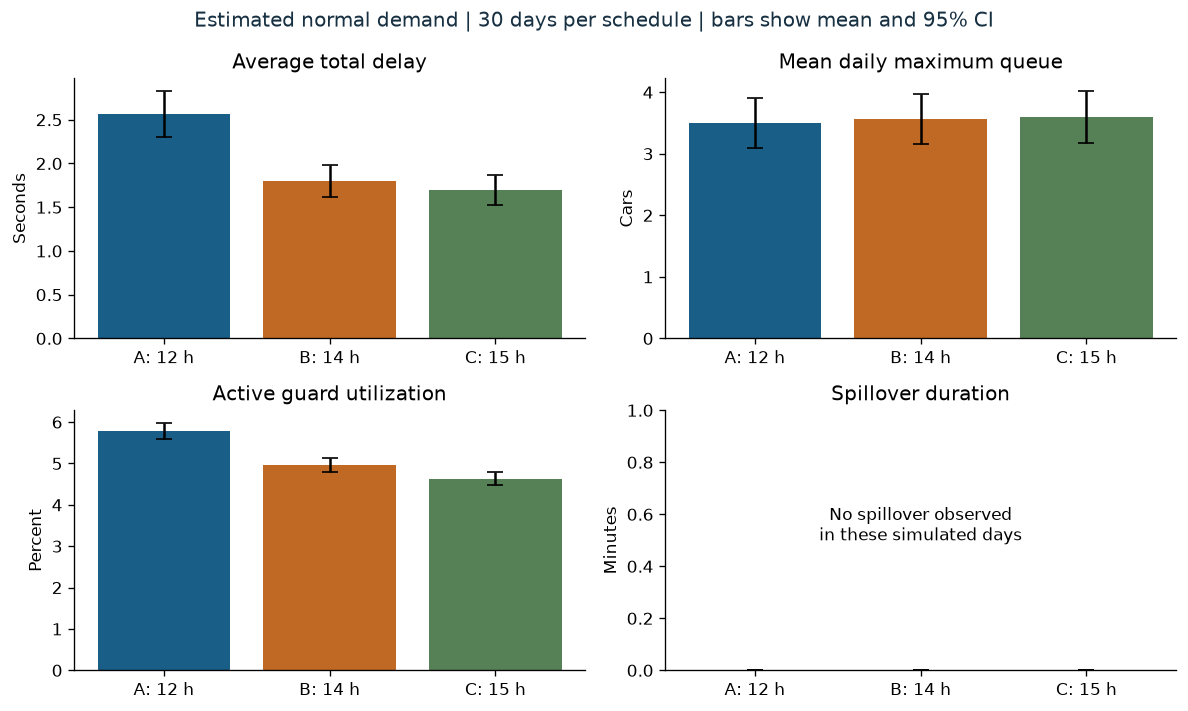

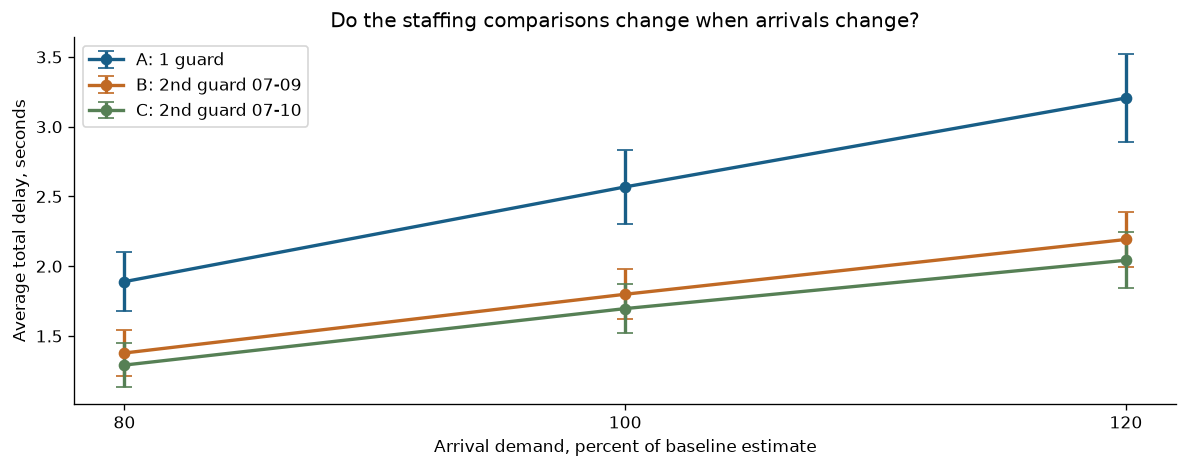

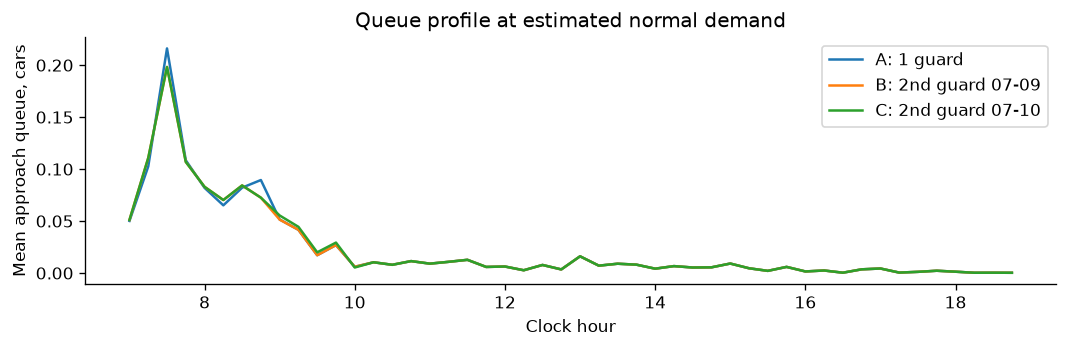

In [10]:
from tools.build_presentation import draw_results, draw_sensitivity
fig = draw_results(summary)
fig.savefig(FIGS / "measures_ci.png",bbox_inches="tight"); plt.show()
fig = draw_sensitivity(summary)
fig.savefig(FIGS / "demand_sensitivity.png",bbox_inches="tight"); plt.show()
profiles = []
for demand,days in grid_days.items():
    for cfg in ps.CONFIGS:
        values = np.array([ps.mean_queue_by_interval(days[(seed,cfg.name)]) for seed in range(1,final_n+1)])
        for slot in range(48):
            profiles.append({"demand":demand,"configuration":cfg.name,"interval":slot,
                             "mean_queue":values[:,slot].mean(),"p95_day_average_queue":np.percentile(values[:,slot],95)})
profile = pd.DataFrame(profiles)
profile.to_csv(RESULTS / "queue_profile_by_interval.csv",index=False)
fig,ax = plt.subplots(figsize=(9,3))
for cfg in ps.CONFIGS:
    sub = profile[(profile.demand==1.0)&(profile.configuration==cfg.name)]
    ax.plot(sub.interval/4+7,sub.mean_queue,label=cfg.name)
ax.set(xlabel="Clock hour",ylabel="Mean approach queue, cars",title="Queue profile at estimated normal demand")
ax.legend(); fig.tight_layout(); fig.savefig(FIGS / "queue_profile.png"); plt.show()

## 7. Arrival-demand sensitivity
This comparison changes expected arrivals only. Activity times, refusal share, K, and the entrance rules remain fixed.

The arrival profile keeps its shape. A 20% increase does not mean exactly 20% more cars in each day. It also does not test a later or longer peak.

Read the delay table with the confidence intervals and paired differences. Additional staffing uses the same extra guard-hours at every demand level.

In [11]:
delay_table = summary[summary.measure=="avg_delay_sec"].pivot(index="configuration",columns="demand",values="mean")
display(delay_table.rename(columns={.8:"20% fewer cars",1.:"normal demand",1.2:"20% more cars"}).round(3))
supplementary = raw.groupby(["demand","config"],as_index=False).agg(
    initial_wait_sec=("avg_initial_wait_sec","mean"),total_delay_sec=("avg_delay_sec","mean"),
    effective_guard_hours=("effective_guard_hours","mean"))
supplementary.to_csv(RESULTS / "initial_wait_and_guard_hours.csv",index=False)
display(supplementary.round(4))

demand,20% fewer cars,normal demand,20% more cars
configuration,,,
A: 1 guard,1.889,2.569,3.206
B: 2nd guard 07-09,1.378,1.799,2.192
C: 2nd guard 07-10,1.292,1.696,2.043


,demand,config,initial_wait_sec,total_delay_sec,effective_guard_hours
0,0.8,A: 1 guard,1.8895,1.8895,12.0
1,0.8,B: 2nd guard 07-09,0.8984,1.3781,14.0
2,0.8,C: 2nd guard 07-10,0.7251,1.2916,15.0
3,1.0,A: 1 guard,2.5686,2.5686,12.0
4,1.0,B: 2nd guard 07-09,1.2530,1.7992,14.0
5,1.0,C: 2nd guard 07-10,1.0037,1.6965,15.0
6,1.2,A: 1 guard,3.2057,3.2057,12.0
7,1.2,B: 2nd guard 07-09,1.5571,2.1919,14.0
8,1.2,C: 2nd guard 07-10,1.2763,2.0428,15.0


## 8. Activity-time sensitivity
This additional test asks whether timing estimates change the staffing comparison.

Scale sticker checks, ID taps, move-up, and refusals together by 0.8, 1.0, or 1.2. This scales means and standard deviations while preserving distribution shapes.

Keep arrival demand normal. Refusal share, K, and entrance rules remain fixed. The 1.0 cases reuse the main results. Other cases use matching seeds and activity draws.

The same precision targets apply. Activities taking 20% longer differ from 20% more cars arriving. This separate test avoids a large grid of combined changes.

,activity_scale,configuration,n,mean,sd,ci_low,ci_high
0,0.8,A: 1 guard,30,1.539,0.401,1.389,1.688
7,0.8,B: 2nd guard 07-09,30,1.105,0.307,0.990,1.220
14,0.8,C: 2nd guard 07-10,30,1.044,0.293,0.934,1.153
21,1.0,A: 1 guard,30,2.569,0.704,2.306,2.831
28,1.0,B: 2nd guard 07-09,30,1.799,0.483,1.619,1.979
35,1.0,C: 2nd guard 07-10,30,1.696,0.463,1.523,1.869
42,1.2,A: 1 guard,30,3.929,1.210,3.477,4.381
49,1.2,B: 2nd guard 07-09,30,2.687,0.718,2.419,2.955
56,1.2,C: 2nd guard 07-10,30,2.529,0.704,2.266,2.791


,activity_scale,comparison,mean,ci_low,ci_high,bonferroni_ci_low,bonferroni_ci_high
0,0.8,B: 2nd guard 07-09 minus A: 1 guard,-0.434,-0.490,-0.378,-0.504,-0.364
7,0.8,C: 2nd guard 07-10 minus A: 1 guard,-0.495,-0.551,-0.440,-0.564,-0.427
14,0.8,C: 2nd guard 07-10 minus B: 2nd guard 07-09,-0.062,-0.076,-0.047,-0.080,-0.043
21,1.0,B: 2nd guard 07-09 minus A: 1 guard,-0.769,-0.884,-0.654,-0.912,-0.627
28,1.0,C: 2nd guard 07-10 minus A: 1 guard,-0.872,-0.984,-0.760,-1.011,-0.733
35,1.0,C: 2nd guard 07-10 minus B: 2nd guard 07-09,-0.103,-0.126,-0.079,-0.132,-0.073
42,1.2,B: 2nd guard 07-09 minus A: 1 guard,-1.242,-1.470,-1.014,-1.525,-0.959
49,1.2,C: 2nd guard 07-10 minus A: 1 guard,-1.400,-1.622,-1.178,-1.676,-1.124
56,1.2,C: 2nd guard 07-10 minus B: 2nd guard 07-09,-0.158,-0.192,-0.124,-0.200,-0.116


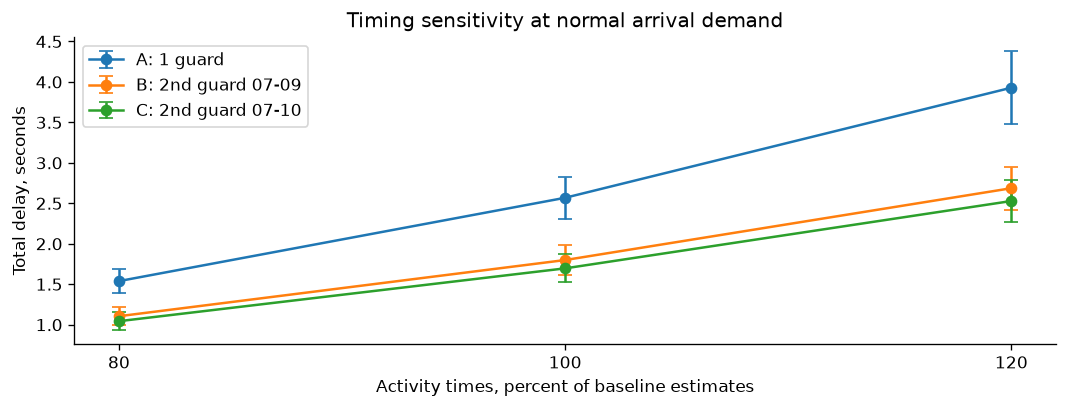

Activity-time targets met: True ; days per case: 30


In [12]:
ACTIVITY_SCALES = [.8, 1., 1.2]
activity_n = final_n

def activity_grid(n):
    frames = []
    for factor in ACTIVITY_SCALES:
        if factor == 1. and n == final_n:
            frame = raw[raw.demand == 1.].copy()
        else:
            frame = ps.run_experiment(range(1, n + 1), rates, model.with_scale(factor), K)
            frame["demand"] = 1.
        frame["activity_scale"] = factor
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

activity_raw = activity_grid(activity_n)
for attempt in range(4):
    activity_plan = precision_plan(activity_raw, "activity_scale")
    if activity_plan.target_met.all() or activity_n >= 300:
        break
    activity_n = min(300, max(activity_n + 1, int(activity_plan.recommended_n.max())))
    activity_raw = activity_grid(activity_n)
activity_plan = precision_plan(activity_raw, "activity_scale")
activity_plan.to_csv(RESULTS / "activity_replication_planning.csv", index=False)
activity_raw.drop(columns=[c for c in activity_raw if c.startswith("_")]).to_csv(
    RESULTS / "activity_replications_raw.csv", index=False)
activity_rows, activity_pair_rows = [], []
for factor in ACTIVITY_SCALES:
    sub = activity_raw[activity_raw.activity_scale == factor]
    by = {cfg.name: sub[sub.config == cfg.name].set_index("seed").sort_index() for cfg in ps.CONFIGS}
    for cfg in ps.CONFIGS:
        for metric, (label, unit) in {**MEASURES, **SUPPLEMENTARY}.items():
            activity_rows.append({"activity_scale": factor, "configuration": cfg.name, "measure": metric,
                                  "label": label, "unit": unit, **ps.ci_mean(by[cfg.name][metric])})
    for a, b in ps.COMPARISONS:
        for metric in {**MEASURES, **SUPPLEMENTARY}:
            difference = by[b.name][metric] - by[a.name][metric]
            adjusted = ps.ci_mean(difference, conf=1-.05/3)
            activity_pair_rows.append({"activity_scale": factor, "comparison": b.name + " minus " + a.name,
                                      "measure": metric, **ps.ci_mean(difference),
                                      "bonferroni_ci_low": adjusted["ci_low"], "bonferroni_ci_high": adjusted["ci_high"]})
activity_summary = pd.DataFrame(activity_rows)
activity_paired = pd.DataFrame(activity_pair_rows)
activity_summary.to_csv(RESULTS / "activity_sensitivity.csv", index=False)
activity_paired.to_csv(RESULTS / "activity_paired_differences.csv", index=False)
check("Activity-test precision", "all stated targets met", activity_n, activity_plan.target_met.all())
for factor in [.8, 1.2]:
    a, non, times = ps.replication_inputs(17, rates, model)
    scaled_a, scaled_non, scaled_times = ps.replication_inputs(17, rates, model.with_scale(factor))
    check(f"Activity scaling {factor}", "same arrivals and types; scaled activities", factor,
          np.array_equal(a, scaled_a) and np.array_equal(non, scaled_non) and
          all(np.allclose(scaled_times[k], times[k] * factor) for k in ps.ACTIVITIES))
display(activity_summary[activity_summary.measure == "avg_delay_sec"][
    ["activity_scale", "configuration", "n", "mean", "sd", "ci_low", "ci_high"]].round(3))
display(activity_paired[activity_paired.measure == "avg_delay_sec"][
    ["activity_scale", "comparison", "mean", "ci_low", "ci_high", "bonferroni_ci_low", "bonferroni_ci_high"]].round(3))
fig, ax = plt.subplots(figsize=(9, 3.5))
for cfg in ps.CONFIGS:
    sub = activity_summary[(activity_summary.configuration == cfg.name) &
                           (activity_summary.measure == "avg_delay_sec")].sort_values("activity_scale")
    ax.errorbar(sub.activity_scale * 100, sub["mean"], yerr=sub.half_width,
                marker="o", capsize=4, label=cfg.name)
ax.set(xticks=[80, 100, 120], xlabel="Activity times, percent of baseline estimates",
       ylabel="Total delay, seconds", title="Timing sensitivity at normal arrival demand")
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / "activity_sensitivity.png"); plt.show()
print("Activity-time targets met:", bool(activity_plan.target_met.all()), "; days per case:", activity_n)


## 9. Reasonableness checks and limitations
Verification asks whether the program follows its rules. Validation asks whether those rules describe the actual entrance well enough for the decision.

Empty demand, high demand, and a slow reader test reasonable responses. These cases provide limited evidence under the assumed rules. They are not campus observations. Independent campus queues are unavailable for comparison.

In [13]:
extreme_rows = []
for name,demand,tap_scale in [("near-zero demand",.01,1.),("normal",1.,1.),("five times demand",5.,1.),("slow reader",1.,10.)]:
    values = []
    for seed in range(501,511):
        a,non,acts = ps.replication_inputs(seed,rates,model,demand)
        acts = {**acts,"tap":acts["tap"]*tap_scale}
        day = ps.simulate_day(a,non,acts,ps.ONE_GUARD)
        values.append(ps.day_metrics(day,K))
    extreme_rows.append({"condition":name,"demand":demand,"tap_scale":tap_scale,
                         "avg_delay_sec":np.mean([x["avg_delay_sec"] for x in values]),
                         "max_queue_veh":np.mean([x["max_queue_veh"] for x in values]),
                         "spillover_min":np.mean([x["spillover_min"] for x in values])})
extremes = pd.DataFrame(extreme_rows).set_index("condition")
check("Extreme low demand","less mean delay than normal",extremes.loc["near-zero demand","avg_delay_sec"],
      extremes.loc["near-zero demand","avg_delay_sec"]<extremes.loc["normal","avg_delay_sec"])
for condition in ["five times demand","slow reader"]:
    check("Extreme "+condition,"higher delay and maximum queue than normal",extremes.loc[condition,"avg_delay_sec"],
          extremes.loc[condition,"avg_delay_sec"]>extremes.loc["normal","avg_delay_sec"] and
          extremes.loc[condition,"max_queue_veh"]>extremes.loc["normal","max_queue_veh"])
extremes.to_csv(RESULTS / "extreme_conditions.csv")
display(extremes.round(3))
assert input_hashes == {p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in DATA.glob("*.csv")}
check("Input provenance","input CSVs unchanged","SHA-256 hashes match",True)

,demand,tap_scale,avg_delay_sec,max_queue_veh,spillover_min
condition,,,,,
near-zero demand,0.01,1.0,-0.000,1.0,0.000
normal,1.00,1.0,2.671,4.0,0.000
five times demand,5.00,1.0,1464.801,296.5,277.564
slow reader,1.00,10.0,412.276,30.0,118.713


## 9b. How much traffic growth can one guard absorb?
The ±20% tests show the result does not depend on small errors in the estimated demand. This sweep asks the decision-maker's follow-up question: **how much would morning traffic have to grow before one guard is no longer enough?** Demand is scaled from 1× to 5× the estimated profile, with all other inputs fixed, for one guard (A) and a second guard 07:00–09:00 (B). Each level uses the same seeds and matching cars as the main experiment.

The tipping point is the first demand level at which the mean spillover reaches at least 1 minute per day.

,demand,configuration,spillover_min_mean,max_queue_mean,morning_delay_sec_mean,spillover_days,p_spillover_day
0,1.0,A: 1 guard,0.000,3.500,3.978,0,0.000
1,1.0,B: 2nd guard 07-09,0.000,3.567,2.541,0,0.000
2,1.5,A: 1 guard,0.064,5.267,7.297,3,0.100
3,1.5,B: 2nd guard 07-09,0.011,5.200,4.255,2,0.067
4,2.0,A: 1 guard,0.828,7.500,12.509,11,0.367
5,2.0,B: 2nd guard 07-09,0.249,6.833,6.502,8,0.267
6,2.5,A: 1 guard,6.415,11.767,25.701,25,0.833
7,2.5,B: 2nd guard 07-09,1.142,9.000,9.750,22,0.733
8,3.0,A: 1 guard,36.551,23.533,75.540,30,1.000
9,3.0,B: 2nd guard 07-09,4.173,11.767,15.166,29,0.967


A: 1 guard: mean spillover first reaches 1 min/day at 2.5x estimated demand
B: 2nd guard 07-09: mean spillover first reaches 1 min/day at 2.5x estimated demand


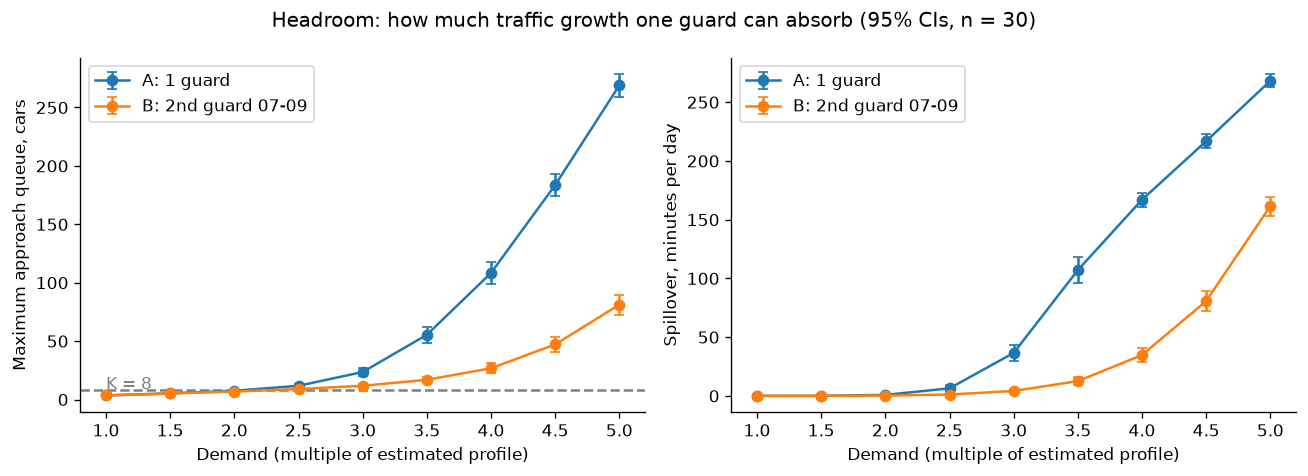

In [14]:
HEADROOM_LEVELS = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
HEADROOM_CONFIGS = [ps.ONE_GUARD, ps.GUARD2_TO_09]
SPILLOVER_TIPPING_MIN = 1.0
sweep = pd.concat([ps.run_experiment(range(1, final_n + 1), rates, model, K, configs=HEADROOM_CONFIGS,
                                     demand=d).assign(demand=d) for d in HEADROOM_LEVELS], ignore_index=True)
headroom_rows = []
for (demand, config), group in sweep.groupby(["demand", "config"], sort=False):
    spill, queue, morning = (ps.ci_mean(group[m]) for m in ["spillover_min", "max_queue_veh", "avg_delay_morning_sec"])
    days_with = int(group.any_spillover.sum())
    p, lo, hi = ps.wilson_interval(days_with, len(group))
    headroom_rows.append({"demand": demand, "configuration": config, "n": len(group),
                          "spillover_min_mean": spill["mean"], "spillover_min_ci_low": spill["ci_low"],
                          "spillover_min_ci_high": spill["ci_high"],
                          "max_queue_mean": queue["mean"], "max_queue_ci_low": queue["ci_low"],
                          "max_queue_ci_high": queue["ci_high"],
                          "morning_delay_sec_mean": morning["mean"],
                          "spillover_days": days_with, "p_spillover_day": p,
                          "p_spillover_ci_low": lo, "p_spillover_ci_high": hi})
headroom = pd.DataFrame(headroom_rows)
headroom.to_csv(RESULTS / "headroom_sweep.csv", index=False)

def tipping_point(config_name):
    rows = headroom[(headroom.configuration == config_name) &
                    (headroom.spillover_min_mean >= SPILLOVER_TIPPING_MIN)]
    return float(rows.demand.min()) if len(rows) else None

tipping = {cfg.name: tipping_point(cfg.name) for cfg in HEADROOM_CONFIGS}
display(headroom[["demand", "configuration", "spillover_min_mean", "max_queue_mean",
                  "morning_delay_sec_mean", "spillover_days", "p_spillover_day"]].round(3))
for name, level in tipping.items():
    print(f"{name}: mean spillover first reaches {SPILLOVER_TIPPING_MIN:g} min/day at "
          + (f"{level:g}x estimated demand" if level else f"no tested level (up to {max(HEADROOM_LEVELS):g}x)"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cfg in HEADROOM_CONFIGS:
    sub = headroom[headroom.configuration == cfg.name]
    axes[0].errorbar(sub.demand, sub.max_queue_mean,
                     yerr=[sub.max_queue_mean - sub.max_queue_ci_low, sub.max_queue_ci_high - sub.max_queue_mean],
                     marker="o", capsize=3, label=cfg.name)
    axes[1].errorbar(sub.demand, sub.spillover_min_mean,
                     yerr=[sub.spillover_min_mean - sub.spillover_min_ci_low, sub.spillover_min_ci_high - sub.spillover_min_mean],
                     marker="o", capsize=3, label=cfg.name)
axes[0].axhline(K, ls="--", color="grey"); axes[0].text(1.0, K + 1, f"K = {K}", color="grey")
axes[0].set(xlabel="Demand (multiple of estimated profile)", ylabel="Maximum approach queue, cars")
axes[1].set(xlabel="Demand (multiple of estimated profile)", ylabel="Spillover, minutes per day")
for ax in axes:
    ax.legend(); ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Headroom: how much traffic growth one guard can absorb (95% CIs, n = {final_n})")
fig.tight_layout(); fig.savefig(FIGS / "headroom_sweep.png", bbox_inches="tight"); plt.show()

## 10. Recommendation
**Decision rule.** The concern behind the study is a line long enough to reach Pablo Ocampo Sr. Extension. A second guard is therefore judged worthwhile only if one guard lets the approach queue reach K under the tested conditions. Time savings are reported beside the extra guard-hours, but savings of a few seconds per car are not treated as a reason to add staff.

The recommendation below is computed from the results, so it updates if the inputs change. It applies under the estimated inputs and the assumed shared-reader entrance; independent booths would need a different model.

In [15]:
normal_delay = summary[(summary.demand == 1.) & (summary.measure == "avg_delay_sec")].set_index("configuration")
normal_morning = supplementary_summary[(supplementary_summary.demand == 1.) &
    (supplementary_summary.measure == "avg_delay_morning_sec")].set_index("configuration")
tradeoff = []
for cfg in ps.CONFIGS:
    tradeoff.append({"schedule": cfg.name, "scheduled_guard_hours": cfg.guard_hours,
                    "all_day_delay_sec": normal_delay.loc[cfg.name, "mean"],
                    "morning_delay_sec": normal_morning.loc[cfg.name, "mean"],
                    "extra_guard_hours": cfg.guard_hours - ps.ONE_GUARD.guard_hours})
display(pd.DataFrame(tradeoff).round(3))
statements = []
for row in paired[(paired.demand == 1.) & (paired.measure == "avg_delay_sec")].itertuples():
    statements.append(f"- {row.comparison}: {-row.mean:.2f} seconds saved per car "
                      f"(paired 95% CI {-row.ci_high:.2f} to {-row.ci_low:.2f}) for "
                      f"{row.extra_guard_hours:g} extra scheduled guard-hours.")
morning = supplementary_paired[(supplementary_paired.demand == 1.) &
                               (supplementary_paired.measure == "avg_delay_morning_sec")]
largest_delay = activity_summary.loc[activity_summary.measure == "avg_delay_sec", "mean"].max()
orders = [sub.sort_values("mean").configuration.tolist()
          for _, sub in activity_summary[activity_summary.measure == "avg_delay_sec"].groupby("activity_scale")]
same_order = all(order == orders[0] for order in orders)
a_name = ps.ONE_GUARD.name
a_main = raw[raw.config == a_name]
a_timing = activity_raw[activity_raw.config == a_name]
a_spill_days = int(a_main.any_spillover.sum()) + int(a_timing.any_spillover.sum())
a_days = len(a_main) + len(a_timing)
a_max_queue = int(max(a_main.max_queue_veh.max(), a_timing.max_queue_veh.max()))
tip_a = tipping[ps.ONE_GUARD.name]
def headroom_value(config, demand, column):
    row = headroom[(headroom.configuration == config.name) & np.isclose(headroom.demand, demand)]
    return float(row[column].iloc[0])

if a_spill_days == 0:
    decision = ("**Recommendation: keep one guard all day (schedule A).** A second guard is not needed at "
                "the estimated demand or within any tested ±20% change to demand or activity times.")
else:
    decision = ("**Recommendation: consider a second guard from 07:00 to 09:00 (schedule B).** One guard "
                f"let the line reach K on {a_spill_days} of {a_days} simulated days in the tested conditions.")
evidence_lines = [
    f"- One guard: spillover on {a_spill_days} of {a_days} simulated days across 80-120% demand and "
    f"80-120% activity times; longest approach queue on any of those days: {a_max_queue} cars (K = {K}).",
    *statements,
    *[f"- Morning arrivals (07:00-10:00), {r.comparison}: {-r.mean:.2f} seconds saved per car."
      for r in morning.itertuples()],
    f"- Across the activity-time test, the largest mean delay was {largest_delay:.2f} seconds, and the "
    f"ranking of schedules {'did not change' if same_order else 'changed'}.",
]
if tip_a:
    spill_a, spill_b = (headroom_value(c, tip_a, "spillover_min_mean") for c in (ps.ONE_GUARD, ps.GUARD2_TO_09))
    when = (f"**When this would change.** One guard first averages at least {SPILLOVER_TIPPING_MIN:g} minute of "
            f"spillover per day at about {tip_a:g}x the estimated demand ({spill_a:.1f} min/day). At that level a "
            f"second guard from 07:00 to 09:00 cuts it to {spill_b:.1f} min/day. If morning arrivals approach "
            f"that level, for example through more sticker holders or a class schedule that concentrates "
            f"arrivals, schedule B becomes worth considering. The same applies if field timings show "
            f"activities several times longer than estimated.")
else:
    when = (f"**When this would change.** One guard stays below {SPILLOVER_TIPPING_MIN:g} minute of spillover "
            f"per day up to {max(HEADROOM_LEVELS):g}x the estimated demand, the largest level tested.")
limits = ("**Limits.** All inputs are group estimates and the shared-reader layout is assumed; no gate "
          "records or field timings were available. The conclusion is therefore conditional on those "
          "inputs, but the headroom sweep shows it would take a large error in demand to overturn it.")
conclusion = "## Recommendation\n\n" + decision + "\n\n" + "\n".join(evidence_lines) + "\n\n" + when + "\n\n" + limits
display(Markdown(conclusion))
(RESULTS / "recommendation.md").write_text(conclusion + "\n")
evidence = pd.DataFrame([
    {"category": "precision", "status": "passed" if plan.target_met.all() else "targets unmet",
     "evidence": f"n={final_n}; replication_followup.csv"},
    {"category": "study design", "status": "complete", "evidence": "3 schedules x 3 demand levels; matching inputs"},
    {"category": "verification", "status": "passed", "evidence": f"{len(checks)} recorded checks"},
    {"category": "field validation", "status": "unavailable", "evidence": "No independent campus measurements"},
    {"category": "arrival sensitivity", "status": "complete", "evidence": "80%, 100%, 120% expected arrivals"},
    {"category": "activity sensitivity", "status": "complete", "evidence": "80%, 100%, 120% activity times at normal arrivals"},
])
evidence.to_csv(RESULTS / "evidence_summary.csv", index=False)
pd.DataFrame(checks).to_csv(RESULTS / "verification_checks.csv", index=False)
display(evidence)
print("STUDY COMPLETE:", len(raw), "main runs;", len(activity_raw), "activity-test rows;",
      len(checks), "checks;", final_n, "days per combination.")


,schedule,scheduled_guard_hours,all_day_delay_sec,morning_delay_sec,extra_guard_hours
0,A: 1 guard,12.0,2.569,3.978,0.0
1,B: 2nd guard 07-09,14.0,1.799,2.541,2.0
2,C: 2nd guard 07-10,15.0,1.696,2.347,3.0


## Recommendation

**Recommendation: keep one guard all day (schedule A).** A second guard is not needed at the estimated demand or within any tested ±20% change to demand or activity times.

- One guard: spillover on 0 of 180 simulated days across 80-120% demand and 80-120% activity times; longest approach queue on any of those days: 7 cars (K = 8).
- B: 2nd guard 07-09 minus A: 1 guard: 0.77 seconds saved per car (paired 95% CI 0.65 to 0.88) for 2 extra scheduled guard-hours.
- C: 2nd guard 07-10 minus A: 1 guard: 0.87 seconds saved per car (paired 95% CI 0.76 to 0.98) for 3 extra scheduled guard-hours.
- C: 2nd guard 07-10 minus B: 2nd guard 07-09: 0.10 seconds saved per car (paired 95% CI 0.08 to 0.13) for 1 extra scheduled guard-hours.
- Morning arrivals (07:00-10:00), B: 2nd guard 07-09 minus A: 1 guard: 1.44 seconds saved per car.
- Morning arrivals (07:00-10:00), C: 2nd guard 07-10 minus A: 1 guard: 1.63 seconds saved per car.
- Morning arrivals (07:00-10:00), C: 2nd guard 07-10 minus B: 2nd guard 07-09: 0.19 seconds saved per car.
- Across the activity-time test, the largest mean delay was 3.93 seconds, and the ranking of schedules did not change.

**When this would change.** One guard first averages at least 1 minute of spillover per day at about 2.5x the estimated demand (6.4 min/day). At that level a second guard from 07:00 to 09:00 cuts it to 1.1 min/day. If morning arrivals approach that level, for example through more sticker holders or a class schedule that concentrates arrivals, schedule B becomes worth considering. The same applies if field timings show activities several times longer than estimated.

**Limits.** All inputs are group estimates and the shared-reader layout is assumed; no gate records or field timings were available. The conclusion is therefore conditional on those inputs, but the headroom sweep shows it would take a large error in demand to overturn it.

,category,status,evidence
0,precision,passed,n=30; replication_followup.csv
1,study design,complete,3 schedules x 3 demand levels; matching inputs
2,verification,passed,30 recorded checks
3,field validation,unavailable,No independent campus measurements
4,arrival sensitivity,complete,"80%, 100%, 120% expected arrivals"
5,activity sensitivity,complete,"80%, 100%, 120% activity times at normal arrivals"


STUDY COMPLETE: 270 main runs; 270 activity-test rows; 30 checks; 30 days per combination.
